In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MLP

# MLP Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [ ]:
DAT = DATA(load=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")                                         # TODO: implement gpu

In [11]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [128]*4

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
n_epochs = 5000

In [12]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
mlp1 = MLP(in_size, h_size, out_size, norm="layer").to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=30, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [14]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 1.1082375049591064
Epoch: 10 - Loss: 0.47863924503326416
Epoch: 20 - Loss: 0.1852409839630127
Epoch: 30 - Loss: 0.07950568944215775
Epoch: 40 - Loss: 0.04497573524713516
Epoch: 50 - Loss: 0.029376119375228882
Epoch: 60 - Loss: 0.02263270504772663
Epoch: 70 - Loss: 0.01848391443490982
Epoch: 80 - Loss: 0.015484443865716457
Epoch: 90 - Loss: 0.013611269183456898
Epoch: 100 - Loss: 0.012790322303771973
Epoch: 110 - Loss: 0.010218534618616104
Epoch: 120 - Loss: 0.009112599305808544
Epoch: 130 - Loss: 0.00940339732915163
Epoch: 140 - Loss: 0.008469953201711178
Epoch: 150 - Loss: 0.008150894194841385
Epoch: 160 - Loss: 0.007408307399600744
Epoch: 170 - Loss: 0.007031211629509926
Epoch: 180 - Loss: 0.006589074619114399
Epoch: 190 - Loss: 0.0071129933930933475
Epoch: 200 - Loss: 0.006692796014249325
Epoch 00210: reducing learning rate of group 0 to 2.8000e-05.
Epoch: 210 - Loss: 0.00634296890348196
Epoch: 220 - Loss: 0.006229412741959095
Epoch: 230 - Loss: 0.005559664219617844

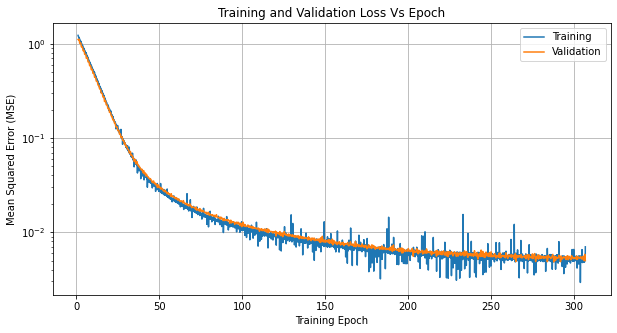

In [15]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [16]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [17]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(3, 90)

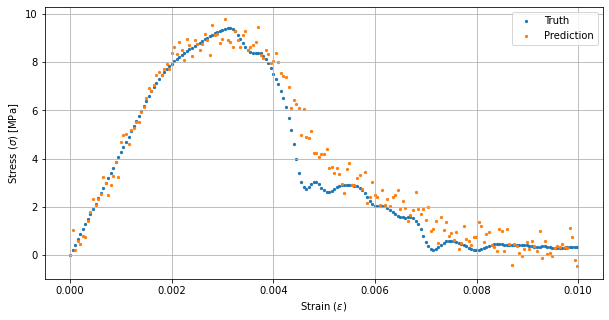

In [19]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=3)

# MLP Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [13]:
DAT1 = DATA(load=True, format=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [14]:
DAT1.train_in1.shape, DAT1.dx_out1.shape

((357, 2), (3588, 357, 1))

In [15]:
in_size = DAT1.train_in1.shape[-1]
out_size = DAT1.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 10

In [16]:
trainDS1x = Dataset_(DAT1.train_in1, DAT1.dx_out1[0])
trainDS1y = Dataset_(DAT1.train_in1, DAT1.dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [18]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 2.089517831802368
Epoch: 10 - Loss: 1.8613141775131226
Best Epoch: 6, with loss 1.7997682094573975


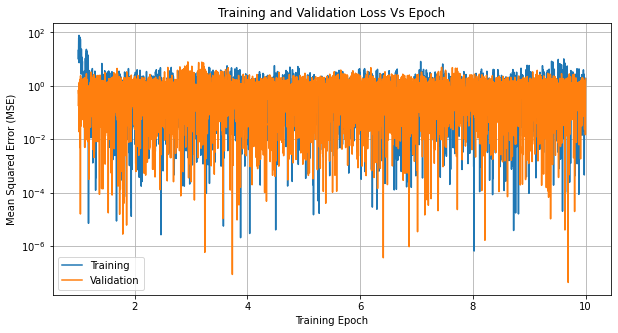

In [19]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [20]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - DAT1.dx_out1[0,:,0]), min(test_outputs[:,0] - DAT1.dx_out1[0,:,0])

(1.3642999093579387, -1.9570156624946549)

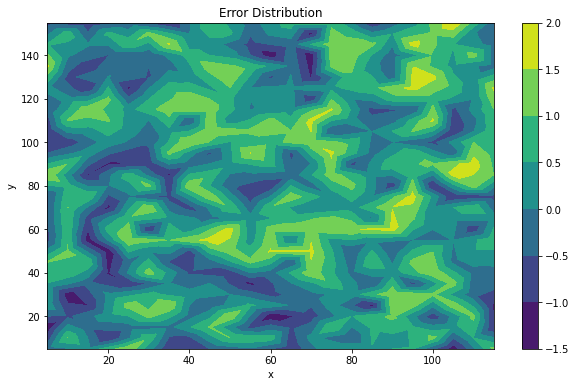

In [21]:
plot_Distribution(DAT1.train_in1, test_outputs[:,0], dx_out1=DAT1.dx_out1[0,:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [26]:
DAT2 = DATA(load=True, format=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [27]:
DAT2.train_in2.shape, DAT2.dx_out2.shape

((2, 714), (3588, 2, 357))

In [28]:
in_size = DAT2.train_in2.shape[-1]
out_size = DAT2.dx_out2.shape[-1]
h_size = []

BATCH_SIZE = 1
LEARNING_RATE = 9e-4
n_epochs = 1000000

h_size[:-1], h_size[1:]

([], [])

In [29]:
trainDS1x = Dataset_(DAT2.train_in2, DAT2.dx_out2[0])
trainDS1y = Dataset_(DAT2.train_in2, DAT2.dy_out2[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [30]:
mlp3 = MLP(in_size, h_size, out_size).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

summary(mlp3, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 357]                  --
├─Linear: 1-1                            [1, 357]                  255,255
Total params: 255,255
Trainable params: 255,255
Non-trainable params: 0
Total mult-adds (M): 0.26
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.02
Estimated Total Size (MB): 1.03

In [31]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 12625.8427734375
Epoch: 10 - Loss: 7526.8837890625
Epoch: 20 - Loss: 3958.119384765625
Epoch: 30 - Loss: 1877.6842041015625
Epoch: 40 - Loss: 753.346435546875
Epoch: 50 - Loss: 230.6542205810547
Epoch: 60 - Loss: 56.59745788574219
Epoch: 70 - Loss: 14.475198745727539
Epoch: 80 - Loss: 1.0758824348449707
Epoch: 90 - Loss: 0.9934263229370117
Epoch: 100 - Loss: 0.2154279500246048
Epoch: 110 - Loss: 0.08918961137533188
Epoch: 120 - Loss: 0.013399372808635235
Epoch: 130 - Loss: 0.010037810541689396
Epoch: 140 - Loss: 0.008003593422472477
Epoch: 150 - Loss: 0.0046406956389546394
Epoch: 160 - Loss: 0.0029701823368668556
Epoch: 170 - Loss: 0.003703380236402154
Epoch 00179: reducing learning rate of group 0 to 2.8000e-05.
Epoch: 180 - Loss: 0.0026299224700778723
Epoch: 190 - Loss: 0.0011882869293913245
Epoch: 200 - Loss: 0.0014105220325291157
Epoch: 210 - Loss: 0.0009514699340797961
Epoch: 220 - Loss: 0.0009551050025038421
Epoch: 230 - Loss: 0.000865713634993881
Epoch: 240 - Lo

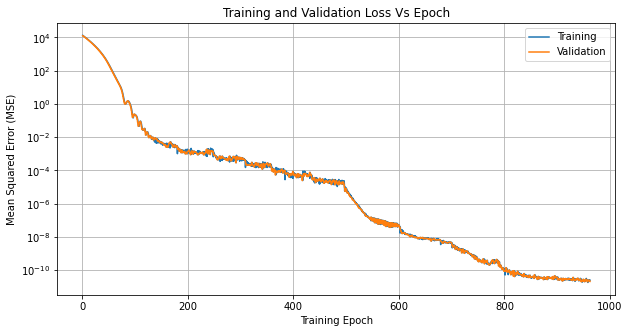

In [32]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [33]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - DAT2.dx_out2[0,0])), min(abs(test_outputs[0] - DAT2.dx_out2[0,0]))

(2.3716151517291784e-05, 3.9062511003606915e-09)

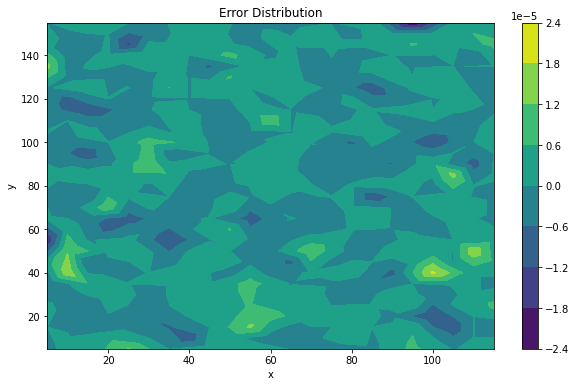

In [34]:
plot_Distribution(DAT2.train_in1, test_outputs[0], dx_out1=DAT2.dx_out2[0,0], typ="contour")

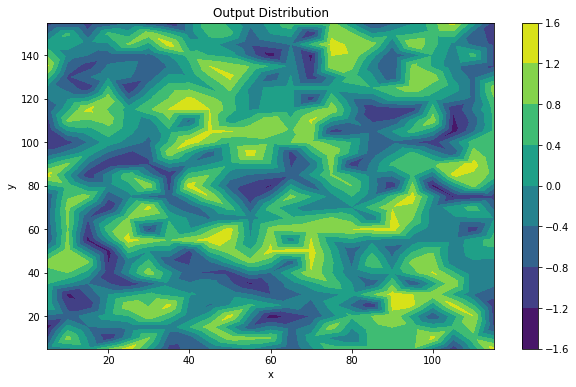

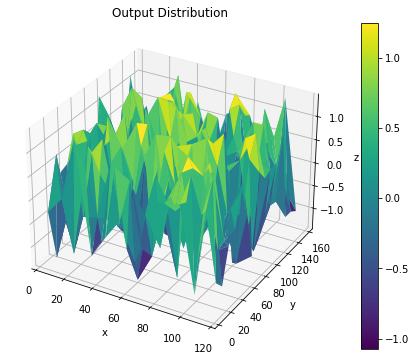

In [35]:
plot_Distribution(DAT2.train_in1, test_outputs[0], typ="both")

In [36]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\n")

fcOUT.weight: torch.Size([357, 714])
tensor([[-0.0685, -0.0179, -0.0724,  ..., -0.0304, -0.0023, -0.0125],
        [-0.0147,  0.0395, -0.0105,  ..., -0.0172,  0.0612, -0.1133],
        [-0.0697,  0.0959, -0.0414,  ...,  0.0273, -0.0789, -0.0440],
        ...,
        [ 0.0777, -0.0969,  0.0552,  ...,  0.0382,  0.0129, -0.0236],
        [-0.0904,  0.0263, -0.1028,  ...,  0.0122,  0.0729,  0.0128],
        [-0.0207, -0.0068,  0.0850,  ...,  0.0208,  0.0113, -0.0417]])

fcOUT.bias: torch.Size([357])
tensor([-7.0901e-04,  6.0077e-05,  6.4487e-04,  2.4921e-03,  3.1055e-04,
         2.7982e-03, -8.5860e-04, -3.9715e-03, -1.7367e-03, -3.9537e-04,
        -5.5548e-03, -2.6586e-03,  2.3485e-03,  2.3114e-03,  1.0984e-03,
         1.2049e-03,  9.7467e-04,  4.6287e-04, -4.5605e-04,  7.1418e-04,
         4.1666e-03, -1.9771e-05, -1.6784e-04, -4.7790e-03, -2.0677e-03,
         2.1065e-04, -8.6245e-05,  1.2814e-03, -4.7245e-05, -2.2860e-03,
         1.4430e-03, -2.4303e-03, -1.0101e-03, -1.4194e-03, 